# MVTec Corruption Experiment

Clean train data로 PatchCore memory bank를 만들고, test data에만 corruption을 적용해서 AUROC drop을 봅니다.

In [1]:
import os
import sys

# Notebook을 MVTec 폴더 안에서 열어도 repo root 기준으로 실행되게 맞춥니다.
if os.path.basename(os.getcwd()) == "MVTec":
    os.chdir("..")

print(os.getcwd())

sys.path.append("..")

/Users/taehayeong/Desktop/lab


In [2]:
import csv

import torch
import pandas as pd
from sklearn.metrics import roc_auc_score

import config_mv
from datasets.mvtec import MyData
from models.backbone import get_backbone
from models.patchcore import PatchCore
from utils.visualization import show_result

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'mps'

In [ ]:
category = config_mv.CLASS_NAME
categories = [category]

corruption = "motion"
corruptions = [corruption]

# severities = [1, 2, 3]
severity = 3
# 빠른 파일럿만 하고 싶으면 예: categories = ["cable"]


In [ ]:
train_data = MyData(category,
        phase="train",
        batch_size=config_mv.BATCH_SIZE,
        shuffle=False,
        limit=config_mv.TRAIN_LIMIT,
        corruption=None,
        severity=0,
                    )
test_data_clean = MyData(category,
        phase="test",
        batch_size=config_mv.BATCH_SIZE,
        shuffle=False,
        limit=config_mv.TEST_LIMIT,
        corruption=None,
        severity=0,
                    )

test_data_corrupt = MyData(category,
        phase="test",
        batch_size=config_mv.BATCH_SIZE,
        shuffle=False,
        limit=config_mv.TEST_LIMIT,
        corruption=corruption,
        severity=severity,
                    )
x_clean, y_clean = test_data_clean[0]
x_corrupt, y_corrupt = test_data_corrupt[0]
x_clean.shape, x_corrupt.shape, y_clean, y_corrupt


(torch.Size([3, 256, 256]), torch.Size([3, 256, 256]), 0, 0)

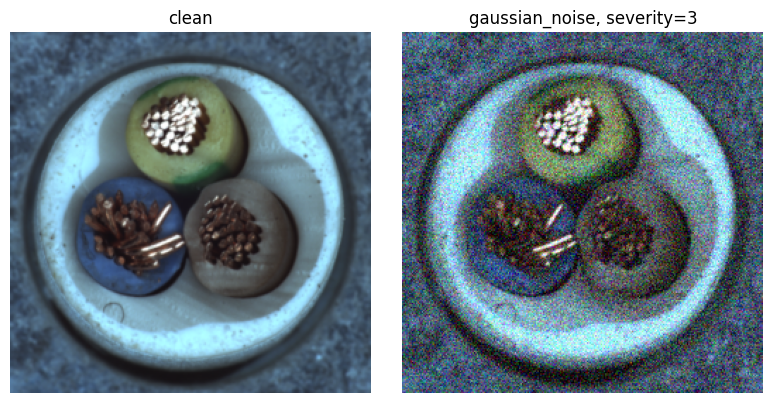

In [ ]:
import matplotlib.pyplot as plt

# Normalize된 tensor를 다시 이미지로 되돌려서 corruption 결과를 확인합니다.
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def tensor_to_image(x):
    x = x.detach().cpu()
    x = x * IMAGENET_STD + IMAGENET_MEAN
    x = x.clamp(0, 1)
    return x.permute(1, 2, 0).numpy()


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(tensor_to_image(x_clean))
axes[0].set_title("clean")
axes[0].axis("off")

axes[1].imshow(tensor_to_image(x_corrupt))
axes[1].set_title(f"{corruption}, severity={severity}")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [7]:
backbone = get_backbone()
patchcore = PatchCore(backbone, k=config_mv.K, device=device)

patchcore.fit(train_data)

In [8]:
scores = []
heatmaps = []
imgs = []
for img, label in test_data_corrupt:
    score, heatmap = patchcore.predict(img)
    scores.append(score.item())
    heatmaps.append(heatmap)
    imgs.append(img)

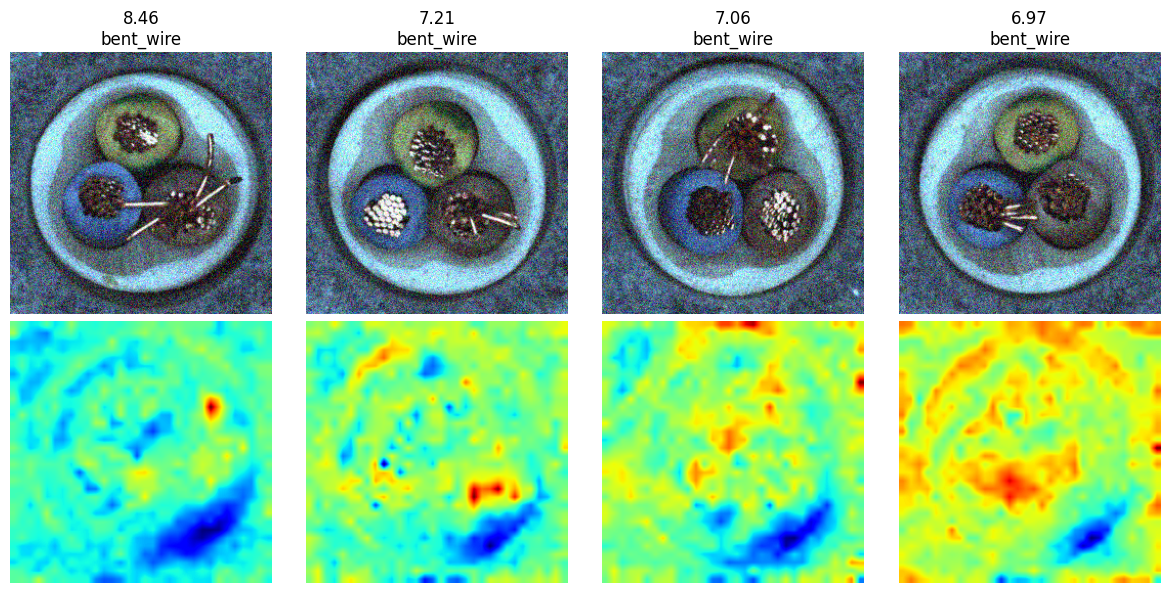

In [10]:
show_result(test_data_corrupt, scores, heatmaps, k=4)

mvtec-v2, 다른ㄷ ㅔ이터에대해서도 실험
얼마나 파였는지도 궁금해

데이터가 적고, 이상에대해 정확하게 탐지.
http://shuoyang1213.me/WIDERFACE/

이지 , 노말 하드로 구분하여 벤치마크

기준에 따른 모델, 옛날 모델 vs 최신 clip기반 모델
모델들과 데이터에대해서 corruption이발생했을때, 난이도 높을때 어떻게변하는지,
모델 최신에따라 어떻게변하는지.
ㄴ

